In [13]:
import pandas as pd

df = pd.read_excel(r"C:\Users\DEEP PC\Desktop\Data set\HR analsyrt project dataset\HR Employee Survey Responses.xlsx")

df.head()
# Library for Ignore the warnings
import warnings
warnings.filterwarnings('always')
warnings.filterwarnings('ignore')

In [14]:
df.shape

(14725, 10)

In [15]:
df.columns

Index(['Response ID', 'Status', 'Department', 'Director', 'Manager',
       'Supervisor', 'Staff', 'Question', 'Response', 'Response Text'],
      dtype='object')

In [16]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14725 entries, 0 to 14724
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Response ID    14725 non-null  int64  
 1   Status         14725 non-null  object 
 2   Department     14725 non-null  object 
 3   Director       14725 non-null  int64  
 4   Manager        14725 non-null  int64  
 5   Supervisor     14725 non-null  int64  
 6   Staff          14725 non-null  int64  
 7   Question       14725 non-null  object 
 8   Response       14590 non-null  float64
 9   Response Text  14590 non-null  object 
dtypes: float64(1), int64(5), object(4)
memory usage: 1.1+ MB


,Response ID,Director,Manager,Supervisor,Staff,Response
count,14725.000000,14725.000000,14725.000000,14725.000000,14725.000000,14590.000000
mean,7359.773990,0.011545,0.072733,0.112869,0.084890,2.984236
std,4247.861393,0.106829,0.259707,0.316444,0.278727,1.020201
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3681.000000,0.000000,0.000000,0.000000,0.000000,3.000000
50%,7362.000000,0.000000,0.000000,0.000000,0.000000,3.000000
75%,11040.000000,0.000000,0.000000,0.000000,0.000000,4.000000
max,14710.000000,1.000000,1.000000,1.000000,1.000000,4.000000


In [17]:
df['Question'].unique()

array(['1. I know what is expected of me at work',
       '2. At work, I have the opportunity to do what I do best every day',
       '3. In the last seven days, I have received recognition or praise for doing good work',
       '4. My supervisor, or someone at work, seems to care about me as a person',
       '5. The mission or purpose of our organization makes me feel my job is important',
       '6. I have a best friend at work',
       '7. This last year, I have had opportunities at work to learn and grow',
       '7. This last year, I have had opportunities at work to learn & grow',
       '8. My supervisor holds employees accountable for performance',
       '9. My department is inclusive and demonstrates support of a diverse workforce',
       '10. Overall I am satisfied with my job',
       '10. Overall I am satisfied with my job '], dtype=object)

In [18]:
df['Question'] = df['Question'].str.strip()

# Fix duplicate wording
df['Question'] = df['Question'].replace({
    '7. This last year, I have had opportunities at work to learn & grow':
    '7. This last year, I have had opportunities at work to learn and grow'
})

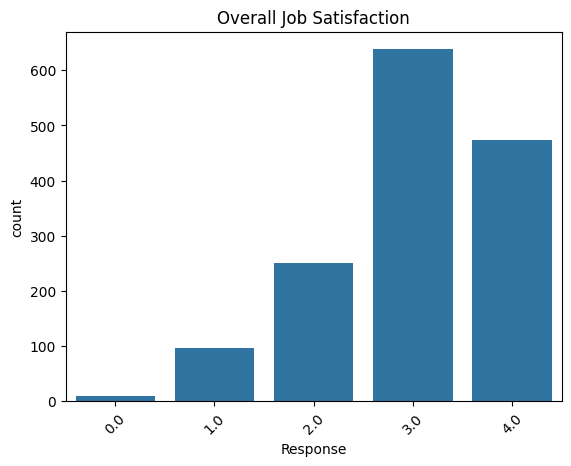

In [19]:
q10 = df[df['Question'] == '10. Overall I am satisfied with my job']

import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Response', data=q10)
plt.title("Overall Job Satisfaction")
plt.xticks(rotation=45)
plt.show()

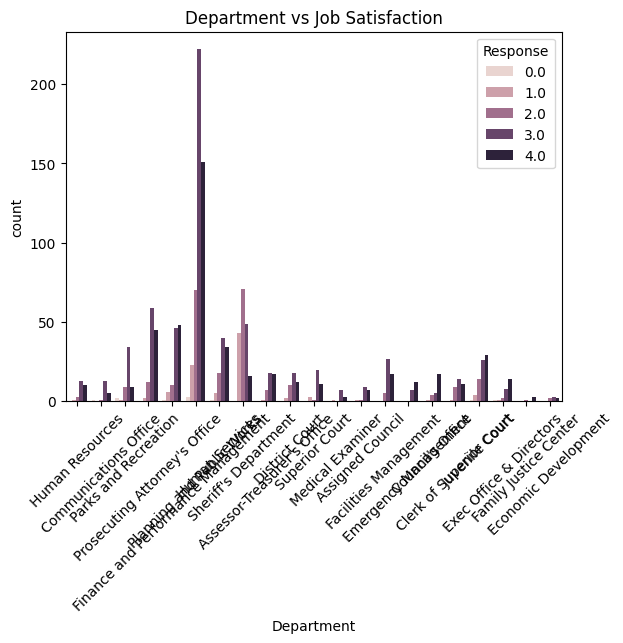

In [20]:
sns.countplot(x='Department', hue='Response', data=q10)
plt.title("Department vs Job Satisfaction")
plt.xticks(rotation=45)
plt.show()

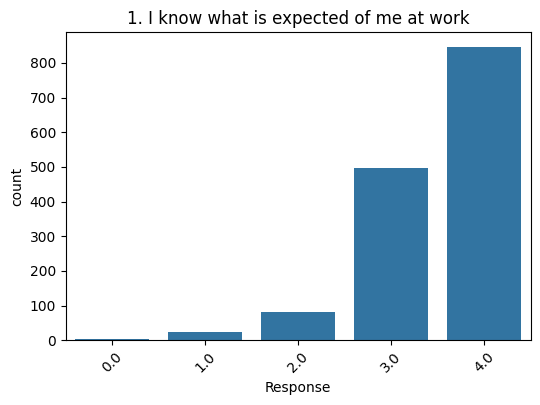

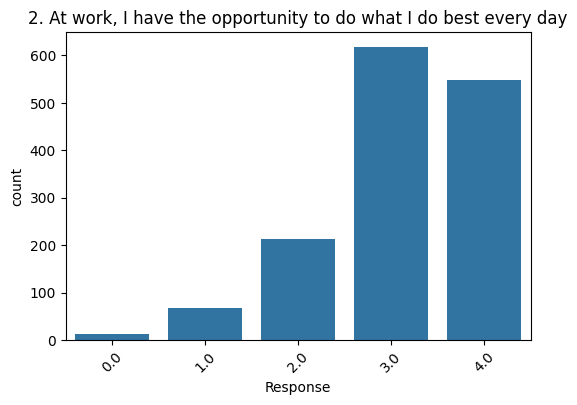

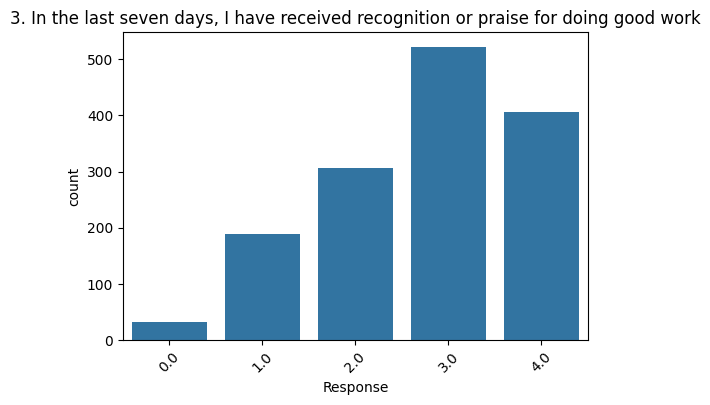

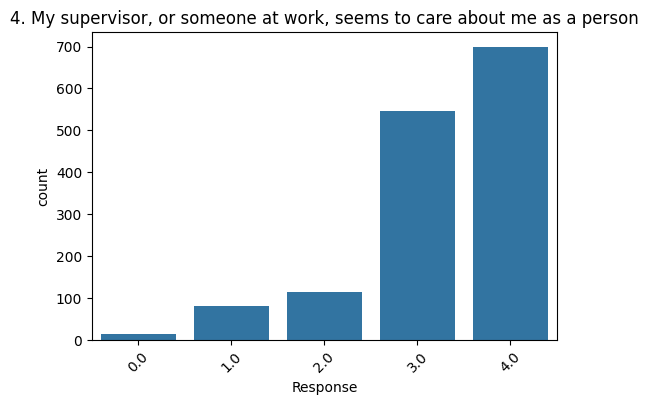

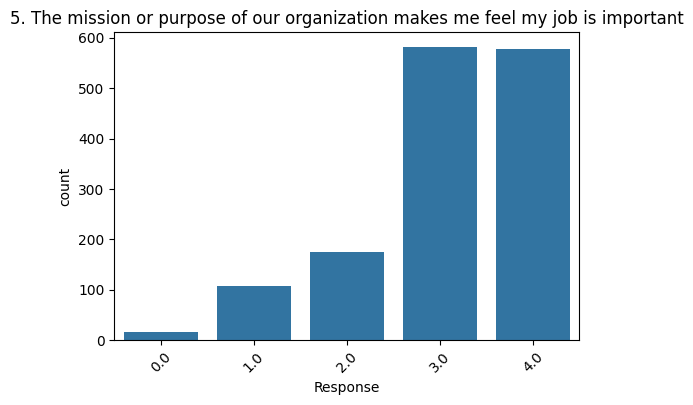

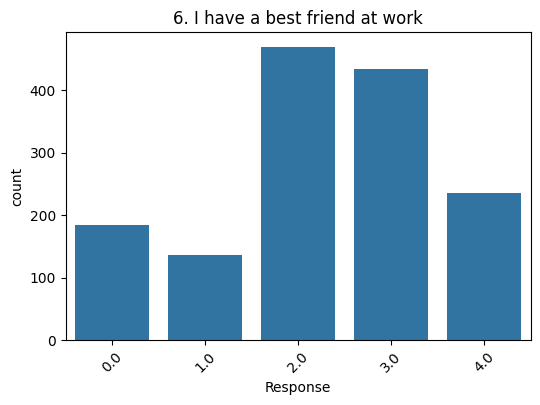

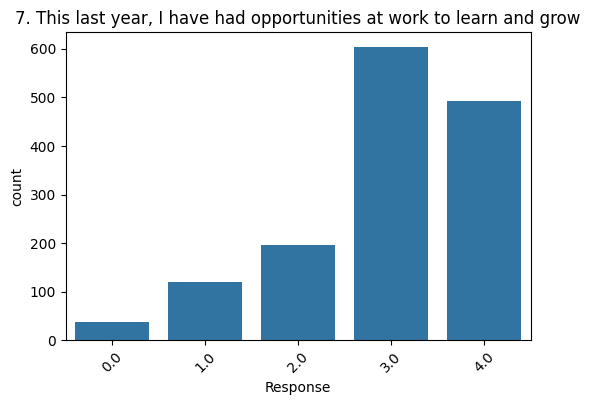

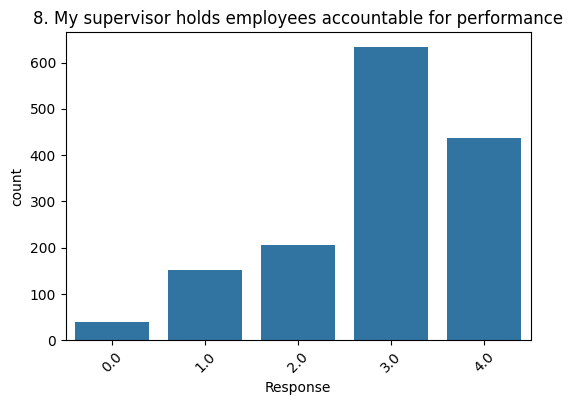

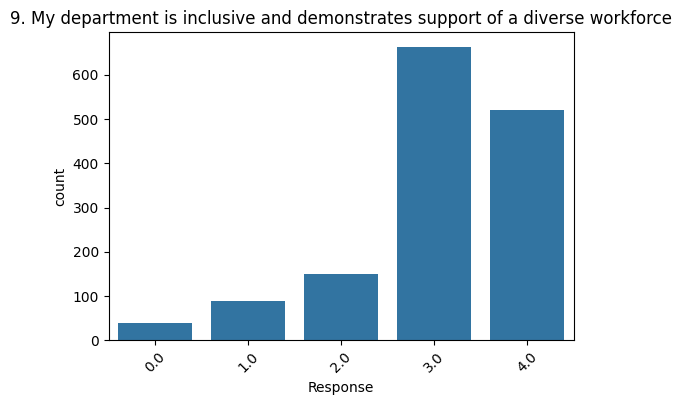

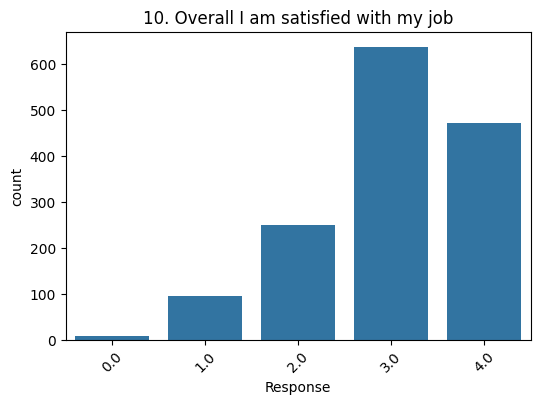

In [21]:
questions = df['Question'].unique()

for q in questions:
    temp = df[df['Question'] == q]
    
    plt.figure(figsize=(6,4))
    sns.countplot(x='Response', data=temp)
    plt.title(q)
    plt.xticks(rotation=45)
    plt.show()

In [22]:
negative = df[df['Response'].isin(['Disagree', 'Strongly Disagree'])]

negative.groupby('Question')['Response'].count().sort_values(ascending=False)

Series([], Name: Response, dtype: int64)

### Key Findings:
Employees clearly understand their job expectations.
Recognition and appreciation are inconsistent across employees.
Some employees lack strong workplace relationships (best friend at work).
Opportunities for growth exist but may vary across departments.
Overall job satisfaction shows mixed responses across workforce.